In [148]:
!pip install catboost
!pip install xgboost

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    recall_score,
    f1_score,
    log_loss,
    classification_report,
    hinge_loss
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

In [150]:
df = pd.read_csv('loan_approval_dataset.csv')

df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [151]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4269, 13)


In [152]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [153]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [154]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [155]:
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [156]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


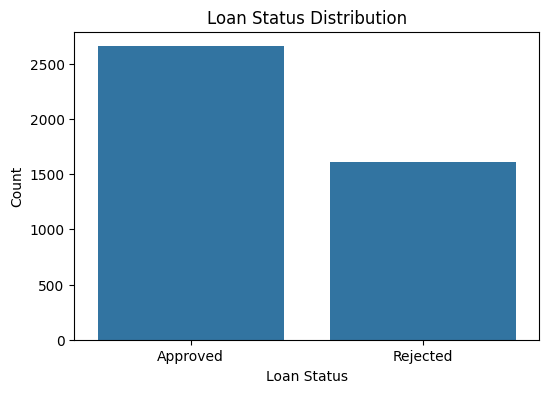

In [157]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Loan Status Distribution')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [158]:
print("Missing Values Count:")

print(df.isnull().sum())

Missing Values Count:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [160]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['education', 'self_employed', 'loan_status'], dtype='object')

Numerical Columns:
Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [161]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [162]:
print("Missing Values After Cleaning:")

print(df.isnull().sum())

Missing Values After Cleaning:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [163]:
df['loan_status'] = df['loan_status'].str.strip().map({
    'Approved': 1,
    'Rejected': 0
})

In [164]:
print(df['loan_status'].value_counts())

loan_status
1    2656
0    1613
Name: count, dtype: int64


In [165]:
#Balance Analysis

In [166]:
class_counts = df['loan_status'].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [167]:
class_percentages = df['loan_status'].value_counts(
    normalize=True
) * 100

print("Class Distribution Percentage:")
print(class_percentages)

Class Distribution Percentage:
loan_status
1    62.215976
0    37.784024
Name: proportion, dtype: float64


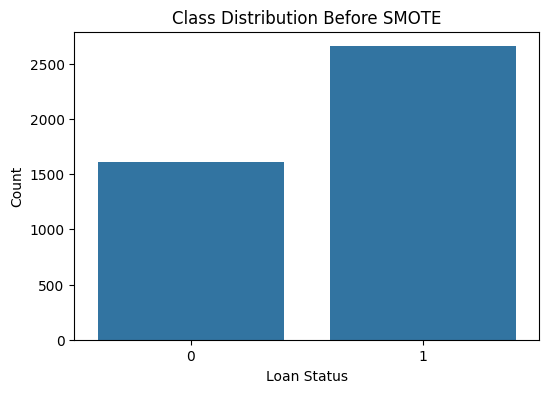

In [168]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Class Distribution Before SMOTE')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [169]:
majority_count = class_counts.max()
minority_count = class_counts.min()

balance_ratio = minority_count / majority_count

print("Majority Class Count:", majority_count)
print("Minority Class Count:", minority_count)
print("Balance Ratio:", balance_ratio)

Majority Class Count: 2656
Minority Class Count: 1613
Balance Ratio: 0.6073042168674698


In [170]:
X = df.drop('loan_status', axis=1)

y = df['loan_status']

In [171]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [172]:
print("Number of Features:", X.shape[1])
print("X Shape:", X.shape)

Number of Features: 12
X Shape: (4269, 12)


In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [174]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (3415, 12)
X_test Shape: (854, 12)
y_train Shape: (3415,)
y_test Shape: (854,)


In [175]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [176]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [177]:
print("Data Preprocessing")

print("X_train Shape:", X_train_scaled.shape)
print("X_test Shape:", X_test_scaled.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

Data Preprocessing
X_train Shape: (3415, 12)
X_test Shape: (854, 12)
y_train Shape: (3415,)
y_test Shape: (854,)


In [178]:
print("Before SMOTE:")

print(y_train.value_counts())

Before SMOTE:
loan_status
1    2125
0    1290
Name: count, dtype: int64


In [179]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [180]:
print("After SMOTE:")

print(y_train_smote.value_counts())

After SMOTE:
loan_status
1    2125
0    2125
Name: count, dtype: int64


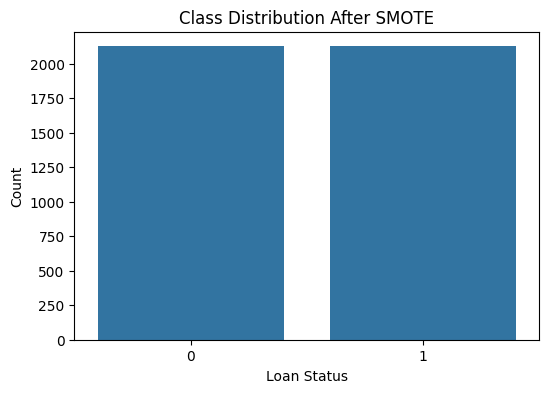

In [181]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train_smote
)

plt.title('Class Distribution After SMOTE')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [182]:
print("Original Training Set:")
print(y_train.value_counts())

print("\nBalanced Training Set:")
print(y_train_smote.value_counts())

Original Training Set:
loan_status
1    2125
0    1290
Name: count, dtype: int64

Balanced Training Set:
loan_status
1    2125
0    2125
Name: count, dtype: int64


In [183]:
print("1) LOGISTIC REGRESSION")

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

1) LOGISTIC REGRESSION


In [184]:
start_time = time.time()

log_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_log = time.time() - start_time

In [185]:
y_train_pred_log = log_model.predict(
    X_train_smote
)

y_test_pred_log = log_model.predict(
    X_test_scaled
)

y_train_probs_log = log_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [186]:
train_acc_log = accuracy_score(
    y_train_smote,
    y_train_pred_log
)

test_acc_log = accuracy_score(
    y_test,
    y_test_pred_log
)

print("Train Accuracy:", train_acc_log)
print("Test Accuracy:", test_acc_log)

Train Accuracy: 0.9254117647058824
Test Accuracy: 0.927400468384075


In [187]:
manual_train_acc_log = sum(
    y_train_smote == y_train_pred_log
) / len(y_train_smote)

manual_test_acc_log = sum(
    y_test == y_test_pred_log
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_log)
print("Manual Test Accuracy:", manual_test_acc_log)

Manual Train Accuracy: 0.9254117647058824
Manual Test Accuracy: 0.927400468384075


In [188]:
loss_log_function = log_loss(
    y_test,
    y_test_probs_log
)

print("Log Loss using function:", loss_log_function)

Log Loss using function: 0.20618848392155073


In [189]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_log,
    epsilon,
    1 - epsilon
)

manual_loss_log = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_log)

Manual Log Loss: 0.20618848392155073


In [190]:
recall_log = recall_score(
    y_test,
    y_test_pred_log
)

f1_log = f1_score(
    y_test,
    y_test_pred_log
)

print("Recall Score:", recall_log)
print("F1 Score:", f1_log)

print(
    f"Training Time: {execution_time_log:.4f} seconds"
)

Recall Score: 0.9246704331450094
F1 Score: 0.9406130268199234
Training Time: 0.0328 seconds


In [191]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_log
    )
)

Confusion Matrix
[[301  22]
 [ 40 491]]


In [192]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_log
    )
)

print("Test Accuracy:", test_acc_log)

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       323
           1       0.96      0.92      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854

Test Accuracy: 0.927400468384075


In [193]:
print("2) KNN CLASSIFIER")

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

2) KNN CLASSIFIER


In [194]:
start_time = time.time()

knn_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_knn = time.time() - start_time

In [195]:
y_train_pred_knn = knn_model.predict(
    X_train_smote
)

y_test_pred_knn = knn_model.predict(
    X_test_scaled
)

y_train_probs_knn = knn_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

In [196]:
train_acc_knn = accuracy_score(
    y_train_smote,
    y_train_pred_knn
)

test_acc_knn = accuracy_score(
    y_test,
    y_test_pred_knn
)

print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)

Train Accuracy: 0.9367058823529412
Test Accuracy: 0.8911007025761124


In [197]:
manual_train_acc_knn = sum(
    y_train_smote == y_train_pred_knn
) / len(y_train_smote)

manual_test_acc_knn = sum(
    y_test == y_test_pred_knn
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_knn)
print("Manual Test Accuracy:", manual_test_acc_knn)

Manual Train Accuracy: 0.9367058823529412
Manual Test Accuracy: 0.8911007025761124


In [198]:
manual_train_acc_knn = sum(
    y_train_smote == y_train_pred_knn
) / len(y_train_smote)

manual_test_acc_knn = sum(
    y_test == y_test_pred_knn
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_knn)
print("Manual Test Accuracy:", manual_test_acc_knn)

Manual Train Accuracy: 0.9367058823529412
Manual Test Accuracy: 0.8911007025761124


In [199]:
loss_knn_function = log_loss(
    y_test,
    y_test_probs_knn
)

print("Log Loss using function:", loss_knn_function)

Log Loss using function: 0.7170643693858064


In [200]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_knn,
    epsilon,
    1 - epsilon
)

manual_loss_knn = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_knn)

Manual Log Loss: 0.6959232383046282


In [201]:
recall_knn = recall_score(
    y_test,
    y_test_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_test_pred_knn
)

print("Recall Score:", recall_knn)
print("F1 Score:", f1_knn)

print(
    f"Training Time: {execution_time_knn:.4f} seconds"
)

Recall Score: 0.8813559322033898
F1 Score: 0.9096209912536443
Training Time: 0.0135 seconds


In [202]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_knn
    )
)

Confusion Matrix
[[293  30]
 [ 63 468]]


In [203]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_knn
    )
)

print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       323
           1       0.94      0.88      0.91       531

    accuracy                           0.89       854
   macro avg       0.88      0.89      0.89       854
weighted avg       0.90      0.89      0.89       854

Train Accuracy: 0.9367058823529412
Test Accuracy: 0.8911007025761124


In [204]:
print("3) DECISION TREE")

tree_model = DecisionTreeClassifier(
    random_state=42
)

3) DECISION TREE


In [205]:
start_time = time.time()

tree_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_tree = time.time() - start_time

In [206]:
y_train_pred_tree = tree_model.predict(
    X_train_smote
)

y_test_pred_tree = tree_model.predict(
    X_test_scaled
)

y_train_probs_tree = tree_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_tree = tree_model.predict_proba(
    X_test_scaled
)[:, 1]

In [207]:
train_acc_tree = accuracy_score(
    y_train_smote,
    y_train_pred_tree
)

test_acc_tree = accuracy_score(
    y_test,
    y_test_pred_tree
)

print("Train Accuracy:", train_acc_tree)
print("Test Accuracy:", test_acc_tree)

Train Accuracy: 1.0
Test Accuracy: 0.9800936768149883


In [208]:
manual_train_acc_tree = sum(
    y_train_smote == y_train_pred_tree
) / len(y_train_smote)

manual_test_acc_tree = sum(
    y_test == y_test_pred_tree
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_tree)
print("Manual Test Accuracy:", manual_test_acc_tree)

Manual Train Accuracy: 1.0
Manual Test Accuracy: 0.9800936768149883


In [209]:
loss_tree_function = log_loss(
    y_test,
    y_test_probs_tree
)

print("Log Loss using function:", loss_tree_function)

Log Loss using function: 0.7174966131323088


In [210]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_tree,
    epsilon,
    1 - epsilon
)

manual_loss_tree = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_tree)

Manual Log Loss: 0.6875512808930266


In [211]:
recall_tree = recall_score(
    y_test,
    y_test_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_test_pred_tree
)

print("Recall Score:", recall_tree)
print("F1 Score:", f1_tree)

print(
    f"Training Time: {execution_time_tree:.4f} seconds"
)

Recall Score: 0.9905838041431262
F1 Score: 0.9840972871842844
Training Time: 0.0303 seconds


In [212]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_tree
    )
)

Confusion Matrix
[[311  12]
 [  5 526]]


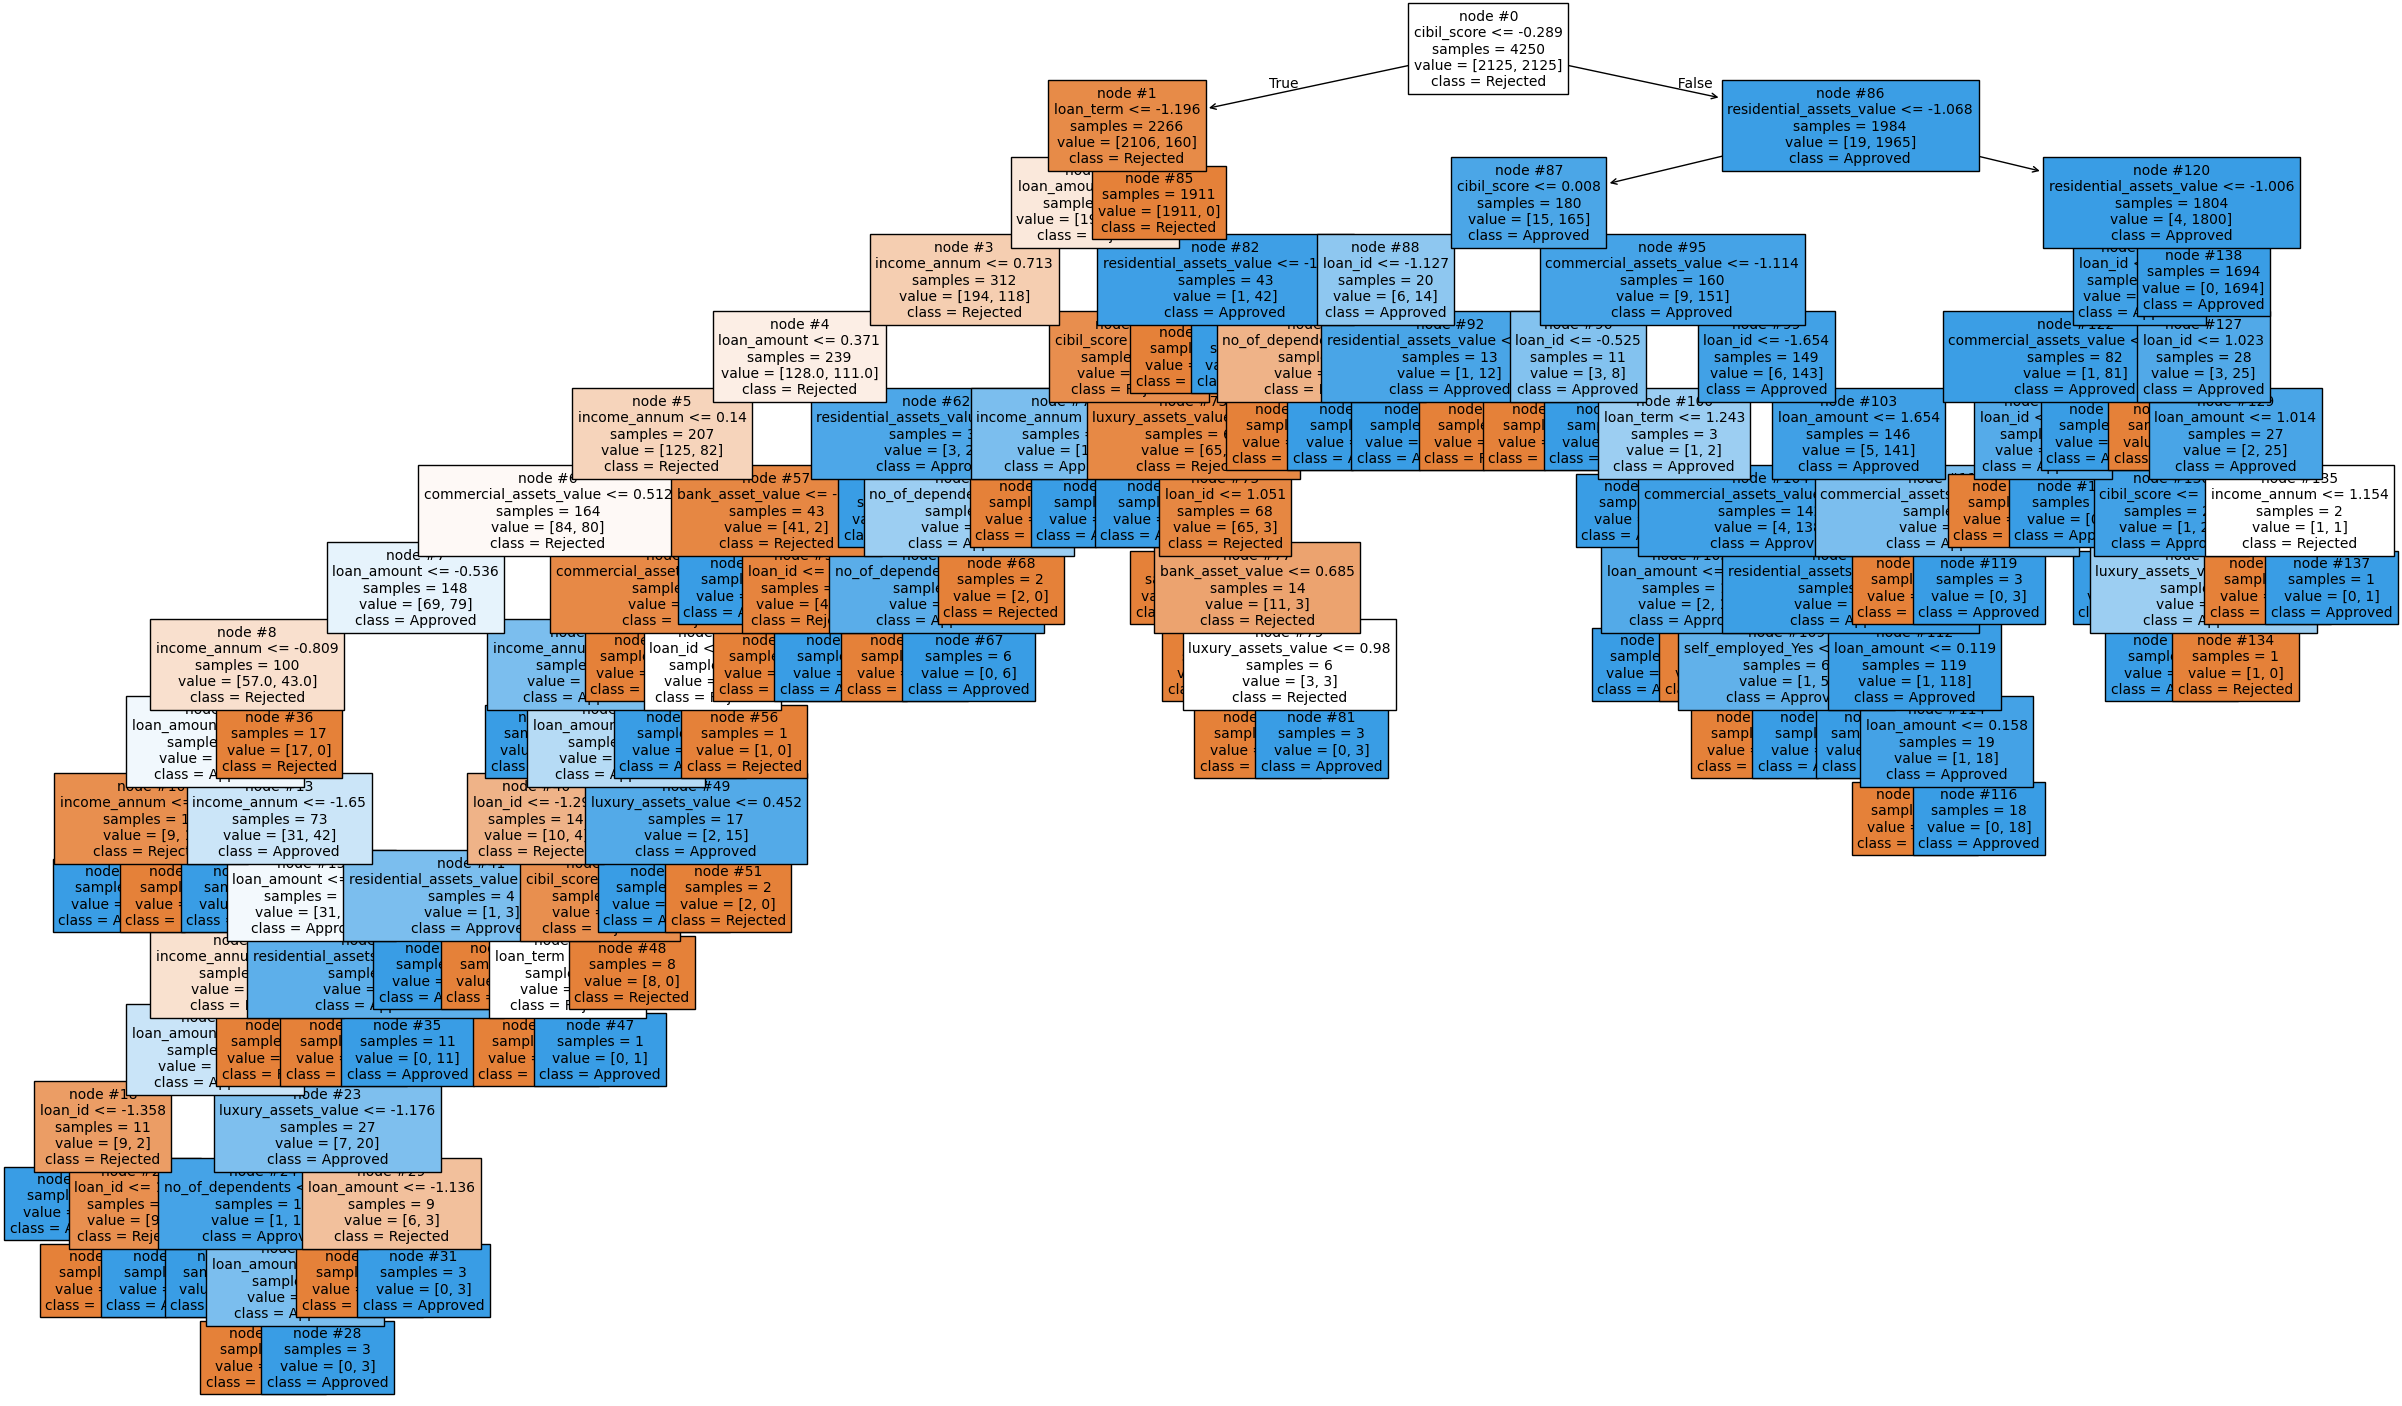

In [213]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(30, 18))

tree.plot_tree(
    tree_model,
    filled=True,
    node_ids=True,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    impurity=False,
    fontsize=10
)

plt.show()

In [214]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_tree
    )
)

print("Train Accuracy:", train_acc_tree)
print("Test Accuracy:", test_acc_tree)

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Train Accuracy: 1.0
Test Accuracy: 0.9800936768149883


In [215]:
print("4) RANDOM FOREST")

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_depth=5,
    random_state=42
)


4) RANDOM FOREST


In [216]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

In [217]:
y_pred = rf_model.predict(X_test_scaled)

print(y_pred)

[1 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1
 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1
 0 0 1 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0
 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1
 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1
 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1
 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0
 0 0 1 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 1 1 0 1 0
 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0
 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1
 1 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1
 1 1 1 1 1 0 0 1 0 0 1 0 

In [218]:
start_time = time.time()

rf_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_rf = time.time() - start_time

In [219]:
y_train_pred_rf = rf_model.predict(
    X_train_smote
)

y_test_pred_rf = rf_model.predict(
    X_test_scaled
)

y_train_probs_rf = rf_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_rf = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

In [220]:
train_acc_rf = accuracy_score(
    y_train_smote,
    y_train_pred_rf
)

test_acc_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Train Accuracy: 0.9705882352941176
Test Accuracy: 0.9718969555035128


In [221]:
manual_train_acc_rf = sum(
    y_train_smote == y_train_pred_rf
) / len(y_train_smote)

manual_test_acc_rf = sum(
    y_test == y_test_pred_rf
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_rf)
print("Manual Test Accuracy:", manual_test_acc_rf)

Manual Train Accuracy: 0.9705882352941176
Manual Test Accuracy: 0.9718969555035128


In [222]:
loss_rf_function = log_loss(
    y_test,
    y_test_probs_rf
)

print("Log Loss using function:", loss_rf_function)

Log Loss using function: 0.15864614001250857


In [223]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_rf,
    epsilon,
    1 - epsilon
)

manual_loss_rf = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_rf)

Manual Log Loss: 0.15864614001250857


In [224]:
recall_rf = recall_score(
    y_test,
    y_test_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_test_pred_rf
)

print("Recall Score:", recall_rf)
print("F1 Score:", f1_rf)

print(
    f"Training Time: {execution_time_rf:.4f} seconds"
)

Recall Score: 0.9623352165725048
F1 Score: 0.9770554493307839
Training Time: 1.5837 seconds


In [225]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_rf
    )
)

Confusion Matrix
[[319   4]
 [ 20 511]]


In [226]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_rf
    )
)

print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       323
           1       0.99      0.96      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9705882352941176
Test Accuracy: 0.9718969555035128


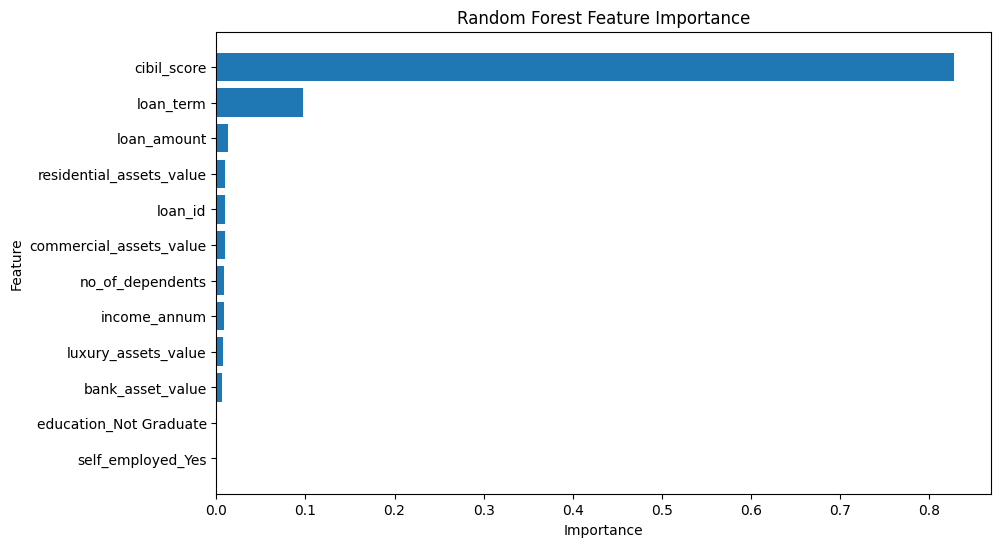

In [227]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [228]:
print("5) SVM (LINEAR KERNEL)")

svm_linear_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

5) SVM (LINEAR KERNEL)


In [229]:
linear_clf = SVC(
    kernel="linear",
    C=1
)

# Refit the linear_clf model using only the two features selected for plotting
linear_clf.fit(X_train_smote[['cibil_score', 'loan_term']], y_train_smote)

SVC(C=1, kernel='linear')

In [230]:
start_time = time.time()

svm_linear_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_svm_linear = time.time() - start_time

In [231]:
y_train_pred_svm_linear = svm_linear_model.predict(
    X_train_smote
)

y_test_pred_svm_linear = svm_linear_model.predict(
    X_test_scaled
)

y_test_probs_svm_linear = svm_linear_model.predict_proba(
    X_test_scaled
)[:, 1]

In [232]:
train_acc_svm_linear = accuracy_score(
    y_train_smote,
    y_train_pred_svm_linear
)

test_acc_svm_linear = accuracy_score(
    y_test,
    y_test_pred_svm_linear
)

print("Train Accuracy:", train_acc_svm_linear)
print("Test Accuracy:", test_acc_svm_linear)

Train Accuracy: 0.9376470588235294
Test Accuracy: 0.9309133489461359


In [233]:
manual_train_acc_svm_linear = sum(
    y_train_smote == y_train_pred_svm_linear
) / len(y_train_smote)

manual_test_acc_svm_linear = sum(
    y_test == y_test_pred_svm_linear
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_svm_linear)
print("Manual Test Accuracy:", manual_test_acc_svm_linear)

Manual Train Accuracy: 0.9376470588235294
Manual Test Accuracy: 0.9309133489461359


In [234]:
decision_values_test = svm_linear_model.decision_function(
    X_test_scaled
)

print("Decision Values:")

print(decision_values_test)

Decision Values:
[ 2.87782993e+00 -3.13623452e+00 -1.97410771e-01  2.28086645e+00
  2.70086938e+00  5.54523493e+00  4.13510224e+00 -1.05402116e+00
  1.04944209e+00 -2.35109342e+00 -3.63649716e+00 -4.55209982e+00
  3.56773801e+00 -2.95129916e+00  2.48511672e+00 -4.94054715e+00
 -2.72783706e-01 -4.06041179e-02  3.11420161e+00 -5.16731481e+00
  5.64896277e+00  4.42691716e+00  2.11840322e+00  5.31286784e+00
  5.48331562e+00 -2.77375208e-01  1.02591239e+00 -2.36934824e-01
  3.32126111e+00  2.51955815e+00  6.78387076e+00 -6.47865857e-01
  3.25177652e+00  2.44588231e+00 -9.00753927e-01  6.12955277e+00
  6.29802439e-01 -3.49875398e+00  4.85078405e+00 -2.17790365e+00
 -4.49617719e+00  2.89520285e+00 -7.71614946e-01  7.00515800e-01
  6.52982932e-01  1.95820408e+00  2.84320889e+00 -5.66137548e-01
 -3.35539335e+00  3.80312317e+00  1.47026988e+00 -4.85815668e-01
  2.35642119e+00  9.42409636e-01 -6.51776729e-01 -3.75142451e+00
  3.49730122e+00 -2.89905035e+00  4.28896968e-02  1.72240585e+00
  3.9115

In [235]:
y_test_svm = np.where(
    y_test == 1,
    1,
    -1
)

hinge_loss_function = hinge_loss(
    y_test_svm,
    decision_values_test
)

print(
    "Hinge Loss using function:",
    hinge_loss_function
)

Hinge Loss using function: 0.19957045563599451


In [236]:
hinge_losses = np.maximum(
    0,
    1 - y_test_svm * decision_values_test
)

manual_hinge_loss = np.mean(
    hinge_losses
)

print(
    "Manual Hinge Loss:",
    manual_hinge_loss
)

Manual Hinge Loss: 0.19957045563599451


In [237]:
recall_svm_linear = recall_score(
    y_test,
    y_test_pred_svm_linear
)

f1_svm_linear = f1_score(
    y_test,
    y_test_pred_svm_linear
)

print("Recall Score:", recall_svm_linear)
print("F1 Score:", f1_svm_linear)

print(
    f"Training Time: {execution_time_svm_linear:.4f} seconds"
)

Recall Score: 0.9246704331450094
F1 Score: 0.9433237271853987
Training Time: 3.4976 seconds


In [238]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_svm_linear
    )
)

Confusion Matrix
[[304  19]
 [ 40 491]]


In [239]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_svm_linear
    )
)

print("Train Accuracy:", train_acc_svm_linear)
print("Test Accuracy:", test_acc_svm_linear)

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       323
           1       0.96      0.92      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854

Train Accuracy: 0.9376470588235294
Test Accuracy: 0.9309133489461359


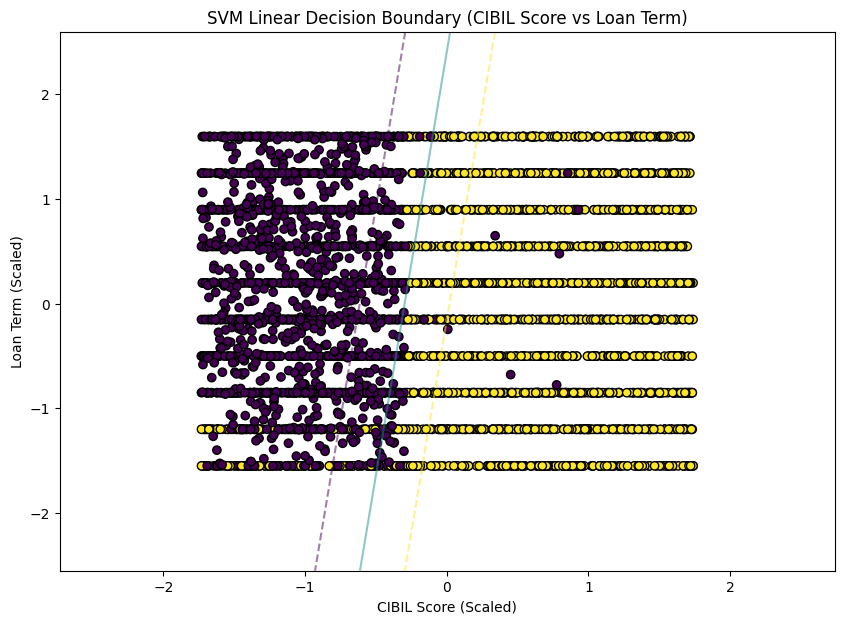

In [240]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(10, 7))
X_train_smote_2d = X_train_smote[['cibil_score', 'loan_term']]
DecisionBoundaryDisplay.from_estimator(
    linear_clf,
    X_train_smote_2d,
    plot_method="contour",
    response_method="decision_function",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    alpha=0.5,
    ax=plt.gca()
)
plt.scatter(
    X_train_smote_2d.iloc[:, 0],
    X_train_smote_2d.iloc[:, 1],
    c=y_train_smote,
    edgecolors="k"
)
plt.xlabel("CIBIL Score (Scaled)")
plt.ylabel("Loan Term (Scaled)")
plt.title("SVM Linear Decision Boundary (CIBIL Score vs Loan Term)")

plt.show()

In [241]:
print("6) SVM (RBF KERNEL)")

svm_rbf_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

6) SVM (RBF KERNEL)


In [242]:
start_time = time.time()

svm_rbf_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_svm_rbf = time.time() - start_time

In [243]:
y_train_pred_svm_rbf = svm_rbf_model.predict(
    X_train_smote
)

y_test_pred_svm_rbf = svm_rbf_model.predict(
    X_test_scaled
)

y_train_probs_svm_rbf = svm_rbf_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_svm_rbf = svm_rbf_model.predict_proba(
    X_test_scaled
)[:, 1]

In [244]:
train_acc_svm_rbf = accuracy_score(
    y_train_smote,
    y_train_pred_svm_rbf
)

test_acc_svm_rbf = accuracy_score(
    y_test,
    y_test_pred_svm_rbf
)

print("Train Accuracy:", train_acc_svm_rbf)
print("Test Accuracy:", test_acc_svm_rbf)

Train Accuracy: 0.96
Test Accuracy: 0.9309133489461359


In [245]:
manual_train_acc_svm_rbf = sum(
    y_train_smote == y_train_pred_svm_rbf
) / len(y_train_smote)

manual_test_acc_svm_rbf = sum(
    y_test == y_test_pred_svm_rbf
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_svm_rbf)
print("Manual Test Accuracy:", manual_test_acc_svm_rbf)

Manual Train Accuracy: 0.96
Manual Test Accuracy: 0.9309133489461359


In [246]:
loss_svm_rbf_function = log_loss(
    y_test,
    y_test_probs_svm_rbf
)

print(
    "Log Loss using function:",
    loss_svm_rbf_function
)

Log Loss using function: 0.15753803397344857


In [247]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_svm_rbf,
    epsilon,
    1 - epsilon
)

manual_loss_svm_rbf = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_svm_rbf)

Manual Log Loss: 0.15753803397344857


In [248]:
recall_svm_rbf = recall_score(
    y_test,
    y_test_pred_svm_rbf
)

f1_svm_rbf = f1_score(
    y_test,
    y_test_pred_svm_rbf
)

print("Recall Score:", recall_svm_rbf)
print("F1 Score:", f1_svm_rbf)

print(
    f"Training Time: {execution_time_svm_rbf:.4f} seconds"
)

Recall Score: 0.9265536723163842
F1 Score: 0.9434324065196549
Training Time: 4.3618 seconds


In [249]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_svm_rbf
    )
)

Confusion Matrix
[[303  20]
 [ 39 492]]


In [250]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_svm_rbf
    )
)

print("Train Accuracy:", train_acc_svm_rbf)
print("Test Accuracy:", test_acc_svm_rbf)

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       323
           1       0.96      0.93      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854

Train Accuracy: 0.96
Test Accuracy: 0.9309133489461359


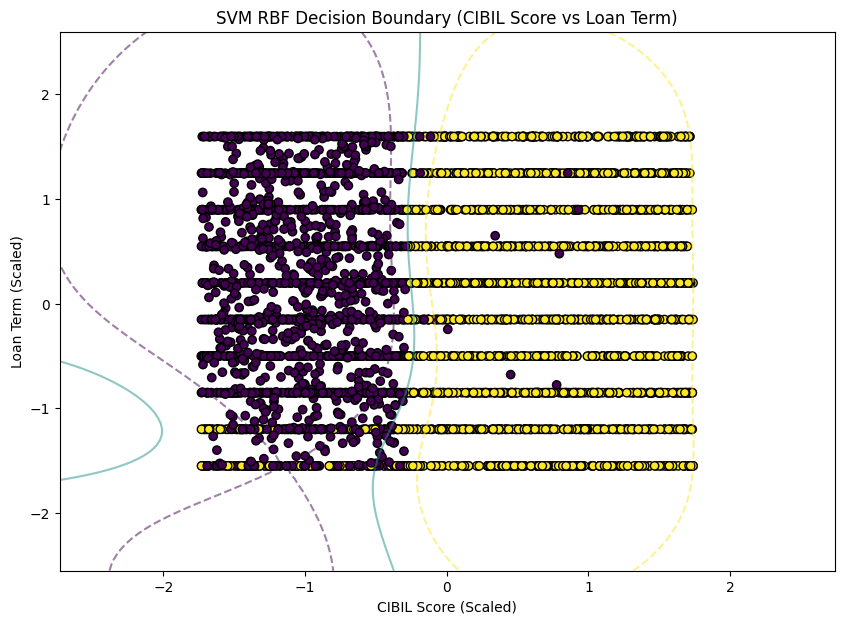

In [251]:
plt.figure(figsize=(10, 7))
X_train_scaled_2d = X_train_smote[['cibil_score', 'loan_term']]

# Create and train a new RBF SVM model specifically for 2D plotting
rbf_clf_2d = SVC(kernel='rbf', probability=True, random_state=42)
rbf_clf_2d.fit(X_train_scaled_2d, y_train_smote)

DecisionBoundaryDisplay.from_estimator(
    rbf_clf_2d,
    X_train_scaled_2d,
    plot_method="contour",
    response_method="decision_function",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    alpha=0.5,
    ax=plt.gca()
)
plt.scatter(
    X_train_scaled_2d.iloc[:, 0],
    X_train_scaled_2d.iloc[:, 1],
    c=y_train_smote,
    edgecolors="k"
)
plt.xlabel("CIBIL Score (Scaled)")
plt.ylabel("Loan Term (Scaled)")
plt.title("SVM RBF Decision Boundary (CIBIL Score vs Loan Term)")

plt.show()

In [252]:
print("7) ADABOOST CLASSIFIER")

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

7) ADABOOST CLASSIFIER


In [253]:
start_time = time.time()

ada_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_ada = time.time() - start_time

In [254]:
y_train_pred_ada = ada_model.predict(
    X_train_smote
)

y_test_pred_ada = ada_model.predict(
    X_test_scaled
)

y_train_probs_ada = ada_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_ada = ada_model.predict_proba(
    X_test_scaled
)[:, 1]

In [255]:
train_acc_ada = accuracy_score(
    y_train_smote,
    y_train_pred_ada
)

test_acc_ada = accuracy_score(
    y_test,
    y_test_pred_ada
)

print("Train Accuracy:", train_acc_ada)
print("Test Accuracy:", test_acc_ada)

Train Accuracy: 0.9781176470588235
Test Accuracy: 0.9718969555035128


In [256]:
manual_train_acc_ada = sum(
    y_train_smote == y_train_pred_ada
) / len(y_train_smote)

manual_test_acc_ada = sum(
    y_test == y_test_pred_ada
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_ada)
print("Manual Test Accuracy:", manual_test_acc_ada)

Manual Train Accuracy: 0.9781176470588235
Manual Test Accuracy: 0.9718969555035128


In [257]:
loss_ada_function = log_loss(
    y_test,
    y_test_probs_ada
)

print(
    "Log Loss using function:",
    loss_ada_function
)

Log Loss using function: 0.4648988567531927


In [258]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_ada,
    epsilon,
    1 - epsilon
)

manual_loss_ada = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_ada)

Manual Log Loss: 0.4648988567531927


In [259]:
recall_ada = recall_score(
    y_test,
    y_test_pred_ada
)

f1_ada = f1_score(
    y_test,
    y_test_pred_ada
)

print("Recall Score:", recall_ada)
print("F1 Score:", f1_ada)

print(
    f"Training Time: {execution_time_ada:.4f} seconds"
)

Recall Score: 0.9717514124293786
F1 Score: 0.9772727272727273
Training Time: 1.5329 seconds


In [260]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_ada
    )
)

Confusion Matrix
[[314   9]
 [ 15 516]]


In [261]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_ada
    )
)

print("Train Accuracy:", train_acc_ada)
print("Test Accuracy:", test_acc_ada)

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       323
           1       0.98      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9781176470588235
Test Accuracy: 0.9718969555035128


In [262]:
print("8) XGBOOST CLASSIFIER")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

8) XGBOOST CLASSIFIER


In [263]:
start_time = time.time()

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_xgb = time.time() - start_time

In [264]:
y_train_pred_xgb = xgb_model.predict(
    X_train_smote
)

y_test_pred_xgb = xgb_model.predict(
    X_test_scaled
)

y_train_probs_xgb = xgb_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

In [265]:
train_acc_xgb = accuracy_score(
    y_train_smote,
    y_train_pred_xgb
)

test_acc_xgb = accuracy_score(
    y_test,
    y_test_pred_xgb
)

print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)

Train Accuracy: 0.9997647058823529
Test Accuracy: 0.9742388758782201


In [266]:
manual_train_acc_xgb = sum(
    y_train_smote == y_train_pred_xgb
) / len(y_train_smote)

manual_test_acc_xgb = sum(
    y_test == y_test_pred_xgb
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_xgb)
print("Manual Test Accuracy:", manual_test_acc_xgb)

Manual Train Accuracy: 0.9997647058823529
Manual Test Accuracy: 0.9742388758782201


In [267]:
loss_xgb_function = log_loss(
    y_test,
    y_test_probs_xgb
)

print(
    "Log Loss using function:",
    loss_xgb_function
)

Log Loss using function: 0.05521242118639067


In [268]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_xgb,
    epsilon,
    1 - epsilon
)

manual_loss_xgb = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_xgb)

Manual Log Loss: 0.05521242118300025


In [269]:
recall_xgb = recall_score(
    y_test,
    y_test_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_test_pred_xgb
)

print("Recall Score:", recall_xgb)
print("F1 Score:", f1_xgb)

print(
    f"Training Time: {execution_time_xgb:.4f} seconds"
)

Recall Score: 0.9774011299435028
F1 Score: 0.9792452830188679
Training Time: 0.9995 seconds


In [270]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_xgb
    )
)

Confusion Matrix
[[313  10]
 [ 12 519]]


In [271]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_xgb
    )
)

print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       323
           1       0.98      0.98      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9997647058823529
Test Accuracy: 0.9742388758782201


In [272]:
print("9) CATBOOST CLASSIFIER")

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

9) CATBOOST CLASSIFIER


In [273]:
start_time = time.time()

cat_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_cat = time.time() - start_time

In [274]:
y_train_pred_cat = cat_model.predict(
    X_train_smote
)

y_test_pred_cat = cat_model.predict(
    X_test_scaled
)

y_train_probs_cat = cat_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_cat = cat_model.predict_proba(
    X_test_scaled
)[:, 1]

In [275]:
train_acc_cat = accuracy_score(
    y_train_smote,
    y_train_pred_cat
)

test_acc_cat = accuracy_score(
    y_test,
    y_test_pred_cat
)

print("Train Accuracy:", train_acc_cat)
print("Test Accuracy:", test_acc_cat)

Train Accuracy: 0.9898823529411764
Test Accuracy: 0.9730679156908665


In [276]:
manual_train_acc_cat = sum(
    y_train_smote == y_train_pred_cat
) / len(y_train_smote)

manual_test_acc_cat = sum(
    y_test == y_test_pred_cat
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_cat)
print("Manual Test Accuracy:", manual_test_acc_cat)

Manual Train Accuracy: 0.9898823529411764
Manual Test Accuracy: 0.9730679156908665


In [277]:
loss_cat_function = log_loss(
    y_test,
    y_test_probs_cat
)

print(
    "Log Loss using function:",
    loss_cat_function
)

Log Loss using function: 0.05921380255341175


In [278]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_cat,
    epsilon,
    1 - epsilon
)

manual_loss_cat = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_cat)

Manual Log Loss: 0.05921380255341175


In [279]:
recall_cat = recall_score(
    y_test,
    y_test_pred_cat
)

f1_cat = f1_score(
    y_test,
    y_test_pred_cat
)

print("Recall Score:", recall_cat)
print("F1 Score:", f1_cat)

print(
    f"Training Time: {execution_time_cat:.4f} seconds"
)

Recall Score: 0.9792843691148776
F1 Score: 0.9783631232361242
Training Time: 0.6572 seconds


In [280]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_cat
    )
)

Confusion Matrix
[[311  12]
 [ 11 520]]


In [281]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_cat
    )
)

print("Train Accuracy:", train_acc_cat)
print("Test Accuracy:", test_acc_cat)

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       323
           1       0.98      0.98      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9898823529411764
Test Accuracy: 0.9730679156908665


In [282]:
print("10) LIGHTGBM CLASSIFIER")

from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1)

10) LIGHTGBM CLASSIFIER


In [283]:
start_time = time.time()

lgb_model.fit(
    X_train_scaled,
    y_train
)

execution_time_lgb = time.time() - start_time

In [284]:
y_train_pred_lgb = lgb_model.predict(
    X_train_scaled
)

y_test_pred_lgb = lgb_model.predict(
    X_test_scaled
)

y_test_probs_lgb = lgb_model.predict_proba(
    X_test_scaled
)[:, 1]

In [285]:
train_acc_lgb = accuracy_score(
    y_train,
    y_train_pred_lgb
)

test_acc_lgb = accuracy_score(
    y_test,
    y_test_pred_lgb
)

print("Train Accuracy:", train_acc_lgb)
print("Test Accuracy:", test_acc_lgb)

Train Accuracy: 1.0
Test Accuracy: 0.9836065573770492


In [286]:
manual_train_acc_lgb = sum(
    y_train == y_train_pred_lgb
) / len(y_train)

manual_test_acc_lgb = sum(
    y_test == y_test_pred_lgb
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_lgb)
print("Manual Test Accuracy:", manual_test_acc_lgb)

Manual Train Accuracy: 1.0
Manual Test Accuracy: 0.9836065573770492


In [287]:
recall_lgb = recall_score(
    y_test,
    y_test_pred_lgb
)
print("Recall Score:", recall_lgb)

Recall Score: 0.9887005649717514


In [288]:
f1_lgb = f1_score(
    y_test,
    y_test_pred_lgb
)
print("F1 Score:", f1_lgb)

F1 Score: 0.9868421052631579


In [289]:
loss_lgb = log_loss(
    y_test,
    y_test_probs_lgb
)
print("Log Loss:", loss_lgb)

Log Loss: 0.04576143307448855


In [290]:
loss_lgb = log_loss(
    y_test,
    y_test_probs_lgb
)

epsilon = 1e-15

p = np.clip(
    y_test_probs_lgb,
    epsilon,
    1 - epsilon
)

manual_loss_lgb = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

In [291]:
summary_data = {

    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM Linear',
        'SVM RBF',
        'AdaBoost',
        'XGBoost',
        'CatBoost',
        'lightboost'
    ],

    'Train Accuracy': [
        train_acc_log,
        train_acc_knn,
        train_acc_tree,
        train_acc_rf,
        train_acc_svm_linear,
        train_acc_svm_rbf,
        train_acc_ada,
        train_acc_xgb,
        train_acc_cat,
        train_acc_lgb
    ],

    'Test Accuracy': [
        test_acc_log,
        test_acc_knn,
        test_acc_tree,
        test_acc_rf,
        test_acc_svm_linear,
        test_acc_svm_rbf,
        test_acc_ada,
        test_acc_xgb,
        test_acc_cat,
        test_acc_lgb
    ],

    'Recall': [
        recall_log,
        recall_knn,
        recall_tree,
        recall_rf,
        recall_svm_linear,
        recall_svm_rbf,
        recall_ada,
        recall_xgb,
        recall_cat,
        recall_lgb
    ],

    'F1 Score': [
        f1_log,
        f1_knn,
        f1_tree,
        f1_rf,
        f1_svm_linear,
        f1_svm_rbf,
        f1_ada,
        recall_xgb * 0 + f1_xgb,
        f1_cat,
        f1_lgb
    ],

    'Loss': [
        loss_log_function,
        loss_knn_function,
        loss_tree_function,
        loss_rf_function,
        hinge_loss_function,
        loss_svm_rbf_function,
        loss_ada_function,
        loss_xgb_function,
        loss_cat_function,
        loss_lgb
    ],

    'Manual Loss': [
        manual_loss_log,
        manual_loss_knn,
        manual_loss_tree,
        manual_loss_rf,
        manual_hinge_loss,
        manual_loss_svm_rbf,
        manual_loss_ada,
        manual_loss_xgb,
        manual_loss_cat,
        manual_loss_lgb
    ],

    'Training Time': [
        execution_time_log,
        execution_time_knn,
        execution_time_tree,
        execution_time_rf,
        execution_time_svm_linear,
        execution_time_svm_rbf,
        execution_time_ada,
        execution_time_xgb,
        execution_time_cat,
        execution_time_lgb
    ]
}

df_summary = pd.DataFrame(summary_data)

df_summary

,Model,Train Accuracy,Test Accuracy,Recall,F1 Score,Loss,Manual Loss,Training Time
0,Logistic Regression,0.925412,0.927400,0.924670,0.940613,0.206188,0.206188,0.032771
1,KNN,0.936706,0.891101,0.881356,0.909621,0.717064,0.695923,0.013475
2,Decision Tree,1.000000,0.980094,0.990584,0.984097,0.717497,0.687551,0.030304
3,Random Forest,0.970588,0.971897,0.962335,0.977055,0.158646,0.158646,1.583746
4,SVM Linear,0.937647,0.930913,0.924670,0.943324,0.199570,0.199570,3.497646
5,SVM RBF,0.960000,0.930913,0.926554,0.943432,0.157538,0.157538,4.361842
6,AdaBoost,0.978118,0.971897,0.971751,0.977273,0.464899,0.464899,1.532901
7,XGBoost,0.999765,0.974239,0.977401,0.979245,0.055212,0.055212,0.999529
8,CatBoost,0.989882,0.973068,0.979284,0.978363,0.059214,0.059214,0.657163
9,lightboost,1.000000,0.983607,0.988701,0.986842,0.045761,0.045761,0.182432


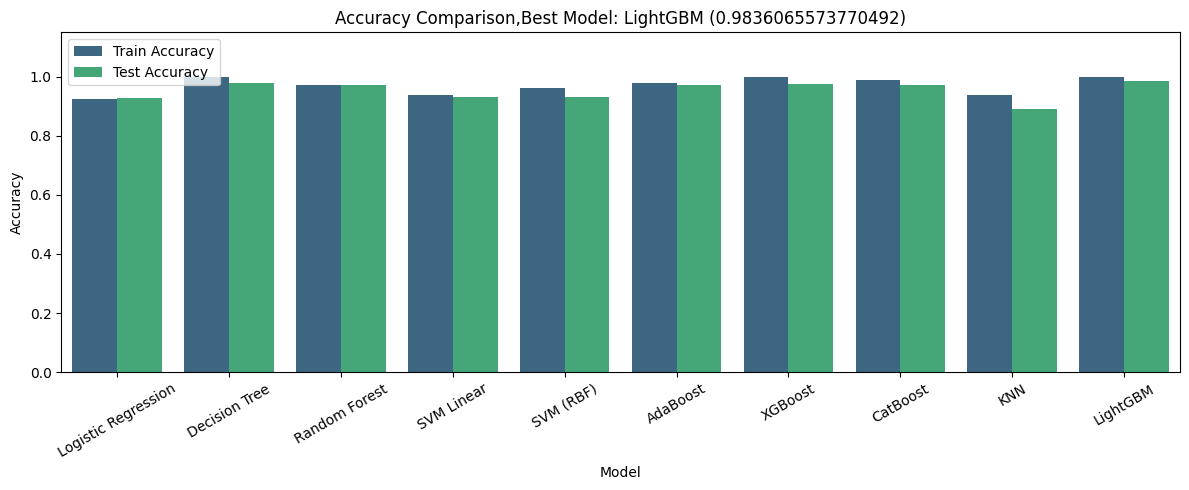

In [292]:
df_plt = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Decision Tree', 'Random Forest',
        'SVM Linear', 'SVM (RBF)', 'AdaBoost',
        'XGBoost', 'CatBoost', 'KNN', 'LightGBM'
    ],
    'Train Accuracy': [
        train_acc_log, train_acc_tree, train_acc_rf,
        train_acc_svm_linear, train_acc_svm_rbf, train_acc_ada,
        train_acc_xgb, train_acc_cat, train_acc_knn, train_acc_lgb
    ],
    'Test Accuracy': [
        test_acc_log, test_acc_tree, test_acc_rf,
        test_acc_svm_linear, test_acc_svm_rbf, test_acc_ada,
        test_acc_xgb, test_acc_cat, test_acc_knn, test_acc_lgb
    ]
})
best_model = df_plt.loc[df_plt['Test Accuracy'].idxmax()]
df_melted = pd.melt(
    df_plt,
    id_vars=['Model'],
    value_vars=['Train Accuracy', 'Test Accuracy'],
    var_name='Accuracy Type',
    value_name='Accuracy'
)
plt.figure(figsize=(12, 5))
sns.barplot(data=df_melted, x='Model', y='Accuracy', hue='Accuracy Type', palette='viridis')

plt.title(f"Accuracy Comparison,Best Model: {best_model['Model']} ({best_model['Test Accuracy']})")
plt.xticks(rotation=30)
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()